Code to apply the method by Ayantika to HYCOM for estimating isotropic spectra

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from xgcm.grid import Grid

In [4]:
dirin = '/Volumes/Salmacis/hycom/zstore/'
filein = dirin + 'hycom12-ssh-1-rechunked-corr.zarr'
ds = xr.open_zarr(filein)

In [5]:
ds

<xarray.Dataset> Size: 366GB
Dimensions:     (time: 720, Y: 7055, X: 9000)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2014-01-01T01:00:00 ... 2014-01-31
  * Y           (Y) int32 28kB 1 2 3 4 5 6 7 ... 7050 7051 7052 7053 7054 7055
  * X           (X) int32 36kB 1 2 3 4 5 6 7 ... 8995 8996 8997 8998 8999 9000
    Latitude    (Y, X) float32 254MB dask.array<chunksize=(7055, 9000), meta=np.ndarray>
    Longitude   (Y, X) float32 254MB dask.array<chunksize=(7055, 9000), meta=np.ndarray>
Data variables:
    ssh         (time, Y, X) float32 183GB dask.array<chunksize=(720, 1, 9000), meta=np.ndarray>
    steric_ssh  (time, Y, X) float32 183GB dask.array<chunksize=(720, 1, 9000), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.0
    experiment:   10.2
    history:      archv2ncdf2d
    source:       HYCOM archive file
    title:        HYCOM

In [6]:
# select a subset of the data
data = ds.isel(time=[0,6,12,18,24])
time = data['time']
ssh = data['ssh']
print(time.values)

['2014-01-01T01:00:00.000000000' '2014-01-01T07:00:00.000000000'
 '2014-01-01T13:00:00.000000000' '2014-01-01T19:00:00.000000000'
 '2014-01-02T01:00:00.000000000']


In [25]:
# South of Gulf Stream: 22-32N, 69-58W (that’s -69 to -58 in longitude)
# select this region
# region = data.where(
#     (data['Latitude'] >= 22) & (data['Latitude'] <= 32) &
#     (data['Longitude'] >= -69) & (data['Longitude'] <= -58),
#     drop=True
# )
# region
dxy = 10
y1 = 22
y2 = y1+dxy
x1 = -69
x2 = x1+dxy
mask = (
    (data["Latitude"] >= y1)
    & (data["Latitude"] <= y2)
    & (data["Longitude"] >= x1)
    & (data["Longitude"] <= x2)
).compute()

In [26]:
region = data.where(mask, drop=True)
region

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 5, Y: 281, X: 251)
Coordinates:
  * time        (time) datetime64[ns] 40B 2014-01-01T01:00:00 ... 2014-01-02T...
  * Y           (Y) int32 1kB 4034 4035 4036 4037 4038 ... 4311 4312 4313 4314
  * X           (X) int32 1kB 5422 5423 5424 5425 5426 ... 5669 5670 5671 5672
    Latitude    (Y, X) float32 282kB 22.04 22.04 22.04 ... 31.99 31.99 31.99
    Longitude   (Y, X) float32 282kB -69.0 -68.96 -68.92 ... -59.08 -59.04 -59.0
Data variables:
    ssh         (time, Y, X) float32 1MB dask.array<chunksize=(5, 1, 251), meta=np.ndarray>
    steric_ssh  (time, Y, X) float32 1MB dask.array<chunksize=(5, 1, 251), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.0
    experiment:   10.2
    history:      archv2ncdf2d
    source:       HYCOM archive file
    title:        HYCOM

In [27]:
#plt.figure(),(region['ssh'][1,:,:]-region['ssh'][0,:,:]).plot()

In [28]:
ssh = region["ssh"]
Longitude = region["Longitude"]
Latitude = region["Latitude"]
nj,ni = ssh.shape[1], ssh.shape[2]
print(nj, ni) # nj in the Y direction, ni in the X direction

281 251


In [29]:
from scipy.signal.windows import tukey

def tukey_window_2d(nj, ni):
    #nj, ni = shape
    tukey_j = tukey(nj)
    tukey_i = tukey(ni)
    return np.outer(tukey_j, tukey_i)

def apply_tukey_window(data):
    nj, ni = data.shape[1], data.shape[2]
    tukey_2d = tukey_window_2d(nj, ni)
    tukey_2d_expanded = np.repeat(tukey_2d[np.newaxis, :, :], data.shape[0], axis=0)    
    data_windowed = np.zeros_like(data)
    for i in range(0,data.shape[0]):
        print(i)
        data_win = (data[i,:,:]) *  tukey_2d_expanded[i,:,:]
        mean_per_time = np.nanmean(data_win)
        data_windowed[i,:,:] = data_win -  mean_per_time
    return data_windowed

# Apply Hann windowing
ssh_windowed= apply_tukey_window(ssh)


0
1
2
3
4


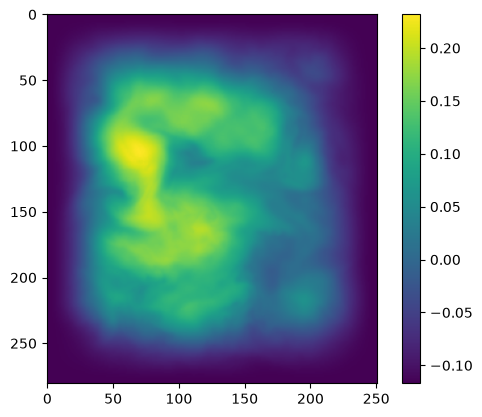

In [30]:
plt.figure()
plt.imshow(ssh_windowed[4,:,:])
plt.colorbar()

In [31]:
def compute_dx_dy_from_latlon(XC, YC):
    """
    Compute mean dx and dy (in meters) using np.gradient over lat-lon grids.
    XC, YC: xarray DataArrays or numpy arrays in degrees (shape: j, i)
    Returns: dx_mean, dy_mean in meters
    """
    R = 6371000  # Earth radius in meters
    deg2rad = np.pi / 180

    lat_rad = np.deg2rad(YC)
    print(lat_rad)
    # Grid spacing in degrees
    dlon = np.gradient(XC, axis=1)  
    dlat = np.gradient(YC, axis=0)
    
    # Convert to meters
    dx = R * np.cos(lat_rad) * deg2rad * dlon  # zonal spacing (j, i)
    dy = R * deg2rad * dlat                    # meridional spacing (j, i)
#     print(dx) 
    # Return mean absolute spacing
    dx_mean = np.abs(dx).mean().item()
    dy_mean = np.abs(dy).mean().item()
    return dx_mean, dy_mean

# Get dx and dy from coordinate grids
dx, dy = compute_dx_dy_from_latlon(Longitude.values,Latitude.values)
dx,dy

[[0.38459674 0.38459674 0.38459674 ... 0.38459674 0.38459674 0.38459674]
 [0.3852438  0.3852438  0.3852438  ... 0.3852438  0.3852438  0.3852438 ]
 [0.38589066 0.38589066 0.38589066 ... 0.38589066 0.38589066 0.38589066]
 ...
 [0.5572261  0.5572261  0.5572261  ... 0.5572261  0.5572261  0.5572261 ]
 [0.55781853 0.55781853 0.55781853 ... 0.55781853 0.55781853 0.55781853]
 [0.5584107  0.5584107  0.5584107  ... 0.5584107  0.5584107  0.5584107 ]]


(3954.877197265625, 3954.862548828125)

In [32]:
np.shape(ssh.values)

(5, 281, 251)

In [33]:
def power_spectrum(data_windowed, dx, dy):
    time_steps, nj, ni = data_windowed.shape
    power_spectra = []
    
    # Create wavenumber arrays
    kx = np.fft.fftfreq(ni, dx) 
    ky = np.fft.fftfreq(nj, dy) 
    k_x = np.fft.fftshift(kx)
    k_y = np.fft.fftshift(ky)
    kx, ky = np.meshgrid(k_x, k_y, indexing="ij")
    dkx = np.diff(k_x)[0]
    dky = np.diff(k_y)[0]
                       
    
#     norm_factor = ((dx * dy)/(ni * nj * dkx * dky ) )  # scaling for Parseval consistency
    norm_factor = 2/(dkx * dky *(ni*nj)**2)                   
    
    for t in range(time_steps):
        # Perform 2D FFT
        fft2 = np.fft.fft2(data_windowed[t,:,:], norm = None)
        
        # Compute power spectrum
        power = ((np.abs(fft2))**2)* norm_factor
        power_shifted = np.fft.fftshift(power)
        power_spectra.append(power_shifted)
    
    # Average power spectrum over time
    #power_spectrum_avg = np.mean(power_spectra, axis=0)
    
    return k_x, k_y, power_spectra


# Compute power spectrum using accurate dx, dy
kx, ky, power_spec_ssh = power_spectrum(ssh_windowed, dx, dy)


In [34]:
power_spec_ssh

[array([[0.57532682, 0.31509318, 0.32976009, ..., 1.69139236, 0.16821513,
         0.80516599],
        [0.17511037, 0.40910732, 0.39228354, ..., 0.14297254, 0.42140953,
         0.14764456],
        [0.42667038, 0.62320961, 0.00271333, ..., 1.44265884, 0.71837867,
         1.01011326],
        ...,
        [1.01011326, 0.71837867, 1.44265884, ..., 0.00271333, 0.62320961,
         0.42667038],
        [0.14764456, 0.42140953, 0.14297254, ..., 0.39228354, 0.40910732,
         0.17511037],
        [0.80516599, 0.16821513, 1.69139236, ..., 0.32976009, 0.31509318,
         0.57532682]], shape=(281, 251)),
 array([[0.03271517, 0.06393503, 0.09044921, ..., 0.5006882 , 0.52349904,
         0.61033598],
        [0.07960876, 0.42526804, 0.09403708, ..., 0.22960029, 0.14656332,
         0.34137743],
        [0.63234761, 0.32482764, 1.03766052, ..., 0.32361113, 0.51130516,
         0.08319066],
        ...,
        [0.08319066, 0.51130516, 0.32361113, ..., 1.03766052, 0.32482764,
         0.63234

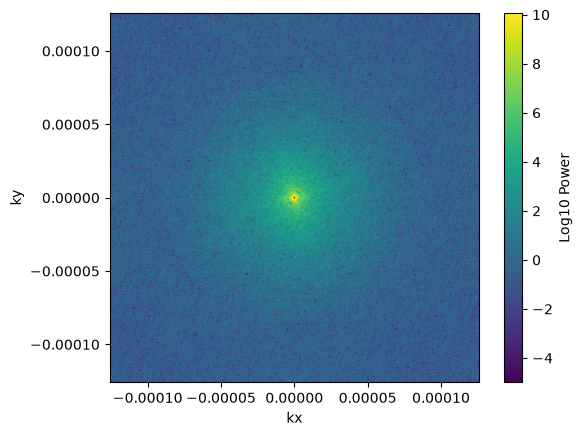

In [35]:
plt.imshow(np.log10(power_spec_ssh[2]), origin="lower", extent=(kx.min(), kx.max(), ky.min(), ky.max()),
           vmin=-5, cmap="viridis")
plt.colorbar(label="Log10 Power")
plt.xlabel("kx")
plt.ylabel("ky")
plt.show()

([<matplotlib.lines.Line2D at 0x11d8b5940>],
 [<matplotlib.lines.Line2D at 0x11d8b5a90>])

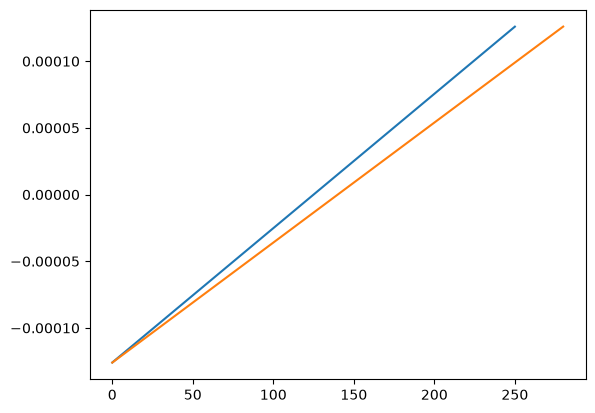

In [36]:
plt.plot(kx),plt.plot(ky)

In [37]:
dkx = np.diff(np.sort(kx))   #[0]
dky = np.diff(np.unique(ky))   #[0]

def isotropic_spectrum(power_spec, kx, ky, N, nfactor):
    """
    Compute isotropic (azimuthally averaged) 1D energy spectral density from 2D power spectrum.

    Parameters:
        power_spec: 2D array of power spectrum (shifted)
        kx, ky: 1D arrays of fftshifted wavenumbers
        N: grid size reference
        nfactor: bin coarsening factor (nbins = N / nfactor)

    Returns:
        k_bins_center: 1D array of bin centers
        E_k: 1D array of isotropic energy spectral density
    """
    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="xy")
    k_grid = np.sqrt(kx_grid**2 + ky_grid**2)
    k_flat = k_grid.ravel()
    power_flat = power_spec.ravel()

    k_min = k_flat.min() #first non zero value np.sort(k_flat)[1] #
    k_max = k_flat.max()

    nbins = int(N / nfactor)
    k_bins = np.linspace(k_min, k_max, nbins + 1)
    k_bins_center = 0.5 * (k_bins[:-1] + k_bins[1:])
    dk = np.diff(k_bins)

    k_idx = np.digitize(k_flat, k_bins) - 1

    E_k = np.zeros(nbins)

    for i in range(nbins):
        bin_mask = (k_idx == i)
        n_points = np.sum(bin_mask)

        if n_points > 0 and k_bins_center[i] > 0:
            E_k[i] = np.mean(power_flat[bin_mask]) * k_bins_center[i] 
        else:
            E_k[i] = np.nan
    
    return k_bins_center, E_k



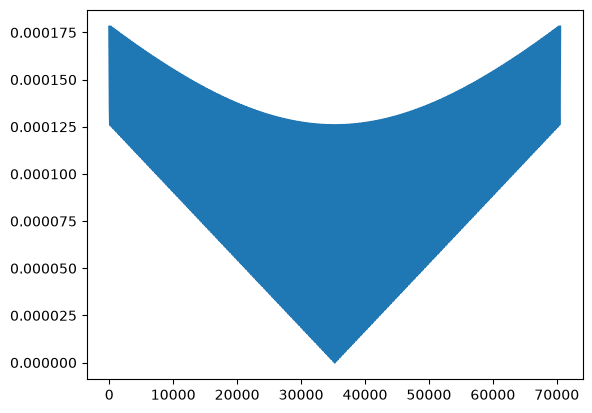

In [38]:
kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="xy")
k_grid = np.sqrt(kx_grid**2 + ky_grid**2)
k_flat = k_grid.ravel()
plt.plot(k_flat)

In [39]:
#Usage
N = np.shape(power_spec_ssh[0])[0] 
print(N)
nfactor = 1
PS = []
k_axis = []

for i in range(0,len(time)):
    k,ps = isotropic_spectrum(power_spec_ssh[i], kx, ky, N, nfactor)
    PS.append(ps)
    k_axis.append(k)

281


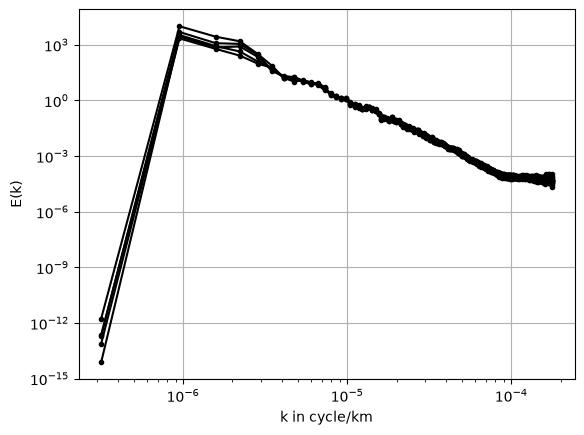

In [40]:
for i in range(0, len(time)):
    plt.plot(k_axis[i], PS[i], color = "black", marker = ".")
    plt.semilogx()
    plt.semilogy()
plt.xlabel('k in cycle/km')
plt.ylabel('E(k)')
plt.grid()


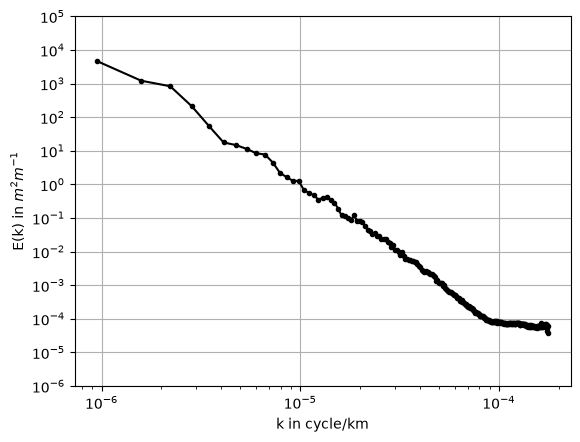

In [41]:
PS_mean = np.mean(PS, axis = 0)
k = k_axis[0]

plt.plot(k[1::], PS_mean[1::], color = "black", marker = ".")
plt.semilogx()
plt.semilogy()
plt.xlabel('k in cycle/km')
plt.ylabel('E(k) in $m^2m^{-1}$')
plt.ylim(1e-6, 1e5)
plt.yticks(10.0**np.arange(-6, 6))
plt.grid()
plt.savefig(f'figs/spectra_{x2-x1}_{y2-y1}.png', dpi=300, bbox_inches='tight')